In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score



In [3]:
!ls /content/covid19_statistics

/content/covid19_statistics


In [6]:
DATA_PATH = "/content/covid19_statistics"

df = pd.read_csv(DATA_PATH)

df.head()

,Unnamed: 0,continent,country,cases.active,cases.critical,cases.recovered,cases.total,deaths.total,population(k),test.total (k),date,time_hms
0,0,Asia,China,118977.0,NaN,379053.0,503302,5272.0,1448471.400,160000.000,2026-01-22,05:00:13
1,1,Africa,Saint-Helena,2164.0,NaN,2.0,2166,NaN,6.115,NaN,2026-01-22,05:00:12
2,2,South-America,Falkland-Islands,0.0,NaN,1930.0,1930,NaN,3.539,8.632,2026-01-22,05:00:12
3,3,North-America,Montserrat,19.0,NaN,1376.0,1403,8.0,4.965,17.762,2026-01-22,05:00:12
4,4,NaN,Diamond-Princess,0.0,NaN,699.0,712,13.0,NaN,NaN,2026-01-22,05:00:12


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape: (237, 12)

Columns:
Index(['Unnamed: 0', 'continent', 'country', 'cases.active', 'cases.critical',
       'cases.recovered', 'cases.total', 'deaths.total', 'population(k)',
       'test.total (k)', 'date', 'time_hms'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       237 non-null    int64  
 1   continent        236 non-null    object 
 2   country          237 non-null    object 
 3   cases.active     190 non-null    float64
 4   cases.critical   59 non-null     float64
 5   cases.recovered  189 non-null    float64
 6   cases.total      237 non-null    int64  
 7   deaths.total     232 non-null    float64
 8   population(k)    229 non-null    float64
 9   test.total (k)   213 non-null    float64
 10  date             237 non-null    object 
 11  time_hms         237 non-null    obje

In [8]:
# Fill numeric columns with mean
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical columns with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Unnamed: 0         0
continent          0
country            0
cases.active       0
cases.critical     0
cases.recovered    0
cases.total        0
deaths.total       0
population(k)      0
test.total (k)     0
date               0
time_hms           0
dtype: int64


In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Unnamed: 0,continent,country,cases.active,cases.critical,cases.recovered,cases.total,deaths.total,population(k),test.total (k),date,time_hms
0,0,2,45,118977.0,1228.220339,379053.0,503302,5272.000000,1.448471e+06,160000.000000,0,11
1,1,0,177,2164.0,1228.220339,2.0,2166,90655.284483,6.115000e+00,32988.287854,0,10
2,2,6,73,0.0,1228.220339,1930.0,1930,90655.284483,3.539000e+00,8.632000,0,10
3,3,4,142,19.0,1228.220339,1376.0,1403,8.000000,4.965000e+00,17.762000,0,10
4,4,0,59,0.0,1228.220339,699.0,712,13.000000,3.469404e+04,32988.287854,0,10


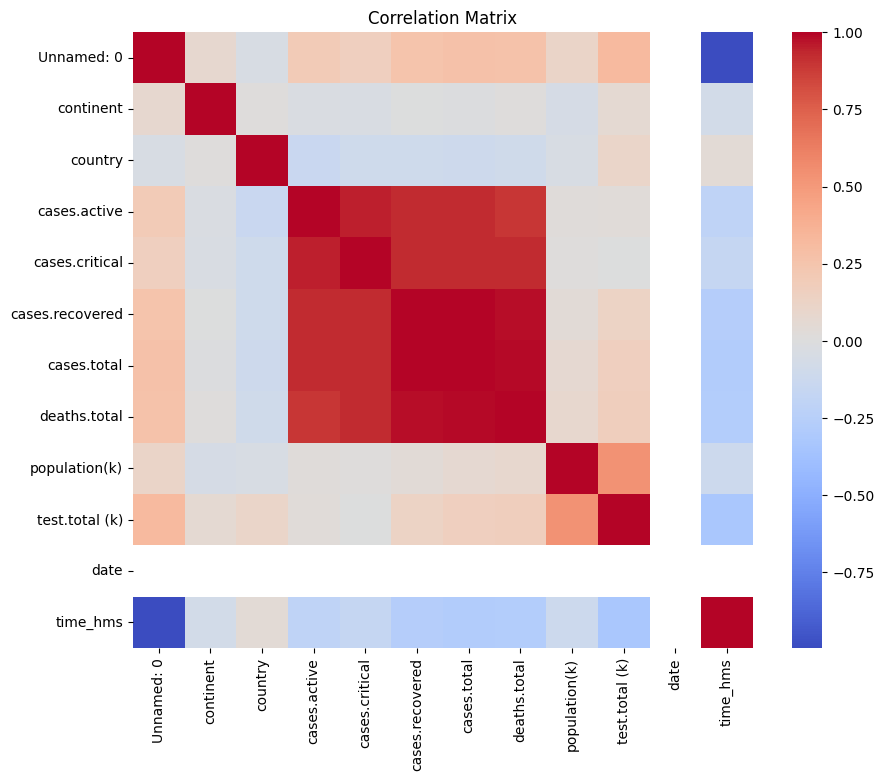

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [13]:
# Show column names first
print("Available Columns:")
print(df.columns)

# 🔽 CHANGE THIS after you see the column names above
target = df.columns[-1]   # Automatically selects the LAST column as target

print("\nSelected target column:", target)

# Split features and target
X = df.drop(columns=[target])
y = df[target]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Available Columns:
Index(['Unnamed: 0', 'continent', 'country', 'cases.active', 'cases.critical',
       'cases.recovered', 'cases.total', 'deaths.total', 'population(k)',
       'test.total (k)', 'date', 'time_hms'],
      dtype='object')

Selected target column: time_hms

X shape: (237, 11)
y shape: (237,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (189, 11)
Testing size: (48, 11)


In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained")

Model Trained


In [16]:
y_pred = model.predict(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[ 5.4473032   9.8568694   1.38351437  4.89423333 10.25776341]


In [17]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.11810249283256907
R2 Score: 0.9883335558443561


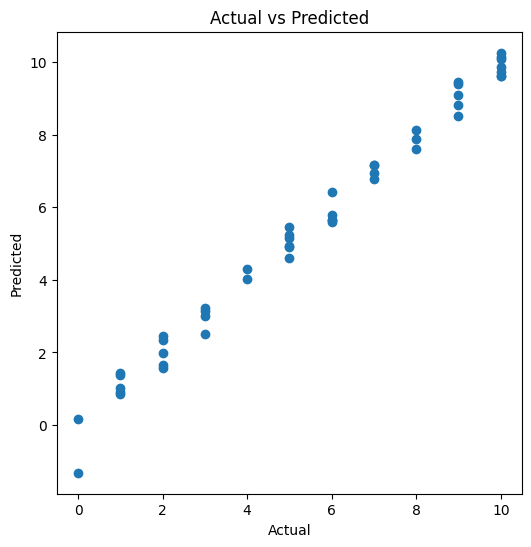

In [18]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()